# Semidefinite Programming in Quantum Information

Juan Manuel Segura Guatibonza

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
import seaborn as sns

# Diseño de los gráficos
sns.set()
sns.set_context("paper")
sns.set_palette("colorblind")

## 1. Linear Programming

### $l_1$ and $l_\infty$ norms

In [ ]:
def l1_norm(y):
    n = len(y)

    # Optimization variable
    x = cp.Variable(n)

    # Vector of ones
    ones = np.ones(n)

    # Objective function
    objective = cp.Minimize(ones.T @ x)

    # Constraints
    constraints = [-x <= y,
                   y <= x]
    
    # Create and solve the problem
    prob = cp.Problem(objective, constraints)
    prob.solve()

    # Get the optimal value
    l1 = prob.value

    return l1

def linf_norm(y):
    n = len(y)

    # Optimization variable
    x = cp.Variable()

    # Vector of ones
    ones = np.ones(n)

    # Objective function
    objective = cp.Minimize(x)

    # Constraints
    constraints = [-x * ones <= y,
                   y <= x * ones]
    
    # Create and solve the problem
    prob = cp.Problem(objective, constraints)
    prob.solve()

    # Get the optimal value
    linf = prob.value

    return linf

In [3]:
array = np.array([1, 2, 3, 4, 5])
print(f'Example array: {array}')
print(f'The l1 norm of this array through the LP is {l1_norm(array)}')
print(f'The l_infty norm of this array through the LP is {linf_norm(array)}')

Example array: [1 2 3 4 5]
The l1 norm of this array through the LP is 14.99999997658794
The l_infty norm of this array through the LP is 5.000000003387259


## 2. Semidefinite Programming

### Maximum eigenvalue, trace norm and operator norm

In [4]:
def Hermitian_matrix(n):
    # Symmetric real part
    A_real = np.random.randn(n, n)
    A_real = A_real + A_real.T
        
    # Antisymmetric imaginary part
    A_imag = np.random.randn(n, n)
    A_imag = A_imag - A_imag.T
        
    # Hermitian matrix
    H = A_real + 1j * A_imag

    return H

def max_eigenvalue(H):
    # Verify that H is Hermitian
    n = H.shape[0]
    assert H.shape[0] == H.shape[1]
    assert np.allclose(H, H.conj().T)

    # Variable (density matrix which is semidefinite positive)
    rho = cp.Variable((n,n), hermitian=True)

    # Objective function
    objective = cp.Maximize(cp.real(cp.trace(H @ rho)))

    # Constraints
    constraints = [cp.trace(rho) == 1,
                   rho >> 0]
    
    # Create the problem
    prob = cp.Problem(objective, constraints)

    # Solve using an SDP solver
    prob.solve(solver=cp.SCS)

    # Results
    max_eigenvalue = prob.value
    optimal_rho = rho.value

    return max_eigenvalue, optimal_rho

def Trace_norm(H):
    # Verify that H is Hermitian
    n = H.shape[0]
    assert H.shape[0] == H.shape[1]
    assert np.allclose(H, H.conj().T)

    # Variable
    X = cp.Variable((n,n), hermitian= True)

    # Objective function
    objective = cp.Minimize(cp.real(cp.trace(X)))

    # Constraints
    constraints = [H + X >> 0,
                   X - H >> 0]
    
    # Create the problem
    prob = cp.Problem(objective, constraints)

    # Solve using an SDP solver
    prob.solve(solver=cp.SCS)

    # Results
    norm = prob.value
    optimal_X = X.value

    return norm, optimal_X

def Operator_norm(H):
    # Verify that H is Hermitian
    n = H.shape[0]
    assert H.shape[0] == H.shape[1]
    assert np.allclose(H, H.conj().T)

    # Identity matrix
    I = np.eye(n)

    # Variable
    x = cp.Variable()

    # Objective function
    objective = cp.Minimize(x)

    # Constraints
    constraints = [H + x * I >> 0,
                   x * I - H >> 0]
    
    # Create the problem
    prob = cp.Problem(objective, constraints)

    # Solve using an SDP solver
    prob.solve(solver=cp.SCS)

    # Results
    norm = prob.value
    optimal_x = x.value

    return norm, optimal_x

In [5]:
H = Hermitian_matrix(3)
print("Hermitian matrix H:")
print(H)

max_lamb, optimal_rho = max_eigenvalue(H)

print(f'The maximum eigenvalue of H is: {max_lamb}')
print('The optimal density operator is:')
print(optimal_rho)

T_norm,_ = Trace_norm(H)
O_norm,_ = Operator_norm(H)

print(f'The trace norm is: {T_norm}')
print(f'The operator norm is: {O_norm}')

Hermitian matrix H:
[[ 1.30389089+0.j          1.09242094-0.8465641j   1.27993359+0.05693319j]
 [ 1.09242094+0.8465641j  -0.01865272+0.j          0.29710019-1.22105829j]
 [ 1.27993359-0.05693319j  0.29710019+1.22105829j  1.23699276+0.j        ]]
The maximum eigenvalue of H is: 2.9974498174650046
The optimal density operator is:
[[0.4511806 +0.j         0.27018805+0.01082493j 0.38114264-0.17099107j]
 [0.27018805-0.01082493j 0.16205421+0.j         0.22414426-0.11153249j]
 [0.38114264+0.17099107j 0.22414426+0.11153249j 0.38676521+0.j        ]]
The trace norm is: 5.962135090052024
The operator norm is: 2.9974260475222754


## 3. Quantum States

### Quantum State Estimation: Trace distance and fidelity

In [6]:
# Computational basis of 2 qubits
ket00 = np.array([1, 0, 0, 0], dtype=complex)
ket01 = np.array([0, 1, 0, 0], dtype=complex)
ket10 = np.array([0, 0, 1, 0], dtype=complex)
ket11 = np.array([0, 0, 0, 1], dtype=complex)
comp_basis = [ket00, ket01, ket10, ket11]

def rand_state(n):
    # Create a random complex matrix
    A = np.random.randn(n, n) + 1j * np.random.randn(n, n)

    # Create a semidefinite positive matrix
    rho = A.conj().T @ A

    # Normalize so the trace is unitary
    rho = rho / np.trace(rho)

    return rho

# Given a basis return the projectors
def projectors(basis):
    M = []

    for ket in basis:
        Med = np.outer(ket, ket.conj())
        M.append(Med)

    return M

def trace_distance(sigma, M, m):
    # Verify dimensions
    n = sigma.shape[0]
    N = len(M)

    assert sigma.shape == (n,n)
    assert len(m) == N

    # Variables
    rho = cp.Variable((n,n), hermitian=True)
    X = cp.Variable((n,n), hermitian=True)

    # Objective function
    objective = cp.Minimize(0.5 * cp.real(cp.trace(X)))

    # Constraints
    constraints = [X - (rho - sigma) >> 0,
                   X + (rho - sigma) >> 0,
                   cp.trace(rho) == 1,
                   rho >> 0]
    for i in range(N):
        constraints.append(cp.real(cp.trace(M[i] @ rho)) == m[i].real)

    # Create the problem and solve
    prob = cp.Problem(objective, constraints)
    try:
        prob.solve(solver=cp.SCS, verbose=False)
    except:
        prob.solve(solver=cp.CVXOPT, verbose=False)

    return prob.value, rho.value

def Fidelity(sigma, M , m):
    # Verify dimensions
    n = sigma.shape[0]
    N = len(M)

    assert sigma.shape == (n,n)
    assert len(m) == N

    # Variables
    rho = cp.Variable((n,n), hermitian=True)
    Y = cp.Variable((n,n), hermitian=True)
    Z = cp.Variable((n,n), hermitian=True)

    # Objective function
    objective = cp.Maximize(cp.real(cp.trace(Y)))

    #
    block_matrix = cp.bmat([[rho, Y + 1j*Z],
                            [Y - 1j*Z, sigma]])
    
    # Constraints
    constraints = [block_matrix >> 0,
                   cp.trace(rho) == 1,
                   rho >> 0]
    for i in range(N):
        constraints.append(cp.real(cp.trace(M[i] @ rho)) == m[i])

    # Create the problem and solve
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.SCS)

    return prob.value**2, rho.value


# Expected values with respect to the computational basis
def expected_values_comp(X, M):
    # Verify dimensions
    n = len(M)

    assert X.shape == (n,n)

    # Array for the expected values
    m = np.zeros(len(M))

    # Calculate all the expected values
    for i, projM in enumerate(M):
        m_exp = np.trace(projM @ X).real
        m[i] = m_exp

    return m

In [7]:
sigma = rand_state(4)
M = projectors(comp_basis)
m = expected_values_comp(sigma, M)

T, rho = trace_distance(sigma, M, m)

print(f'The target matrix is:\n {sigma} \n')
print(f'The expected values of the computational basis are:\n {m} \n')
print(f'The resulting matrix of the SDP of trace distance is: \n {rho} \n')
print(f'The trace distance between rho and sigma is: {T}')

F, rho = Fidelity(sigma, M, m)

print(f'The resulting matrix of the SDP of fidelity is: \n {rho} \n')
print(f'The fidelity between rho and sigma is: {F}')

The target matrix is:
 [[ 0.30125486+0.j          0.16395056+0.00174075j  0.04125728-0.12811947j
  -0.00678061+0.00504453j]
 [ 0.16395056-0.00174075j  0.18446454+0.j          0.03320341-0.0480927j
  -0.09193696-0.07876739j]
 [ 0.04125728+0.12811947j  0.03320341+0.0480927j   0.23392904+0.j
   0.04270363+0.06153972j]
 [-0.00678061-0.00504453j -0.09193696+0.07876739j  0.04270363-0.06153972j
   0.28035157+0.j        ]] 

The expected values of the computational basis are:
 [0.30125486 0.18446454 0.23392904 0.28035157] 

The resulting matrix of the SDP of trace distance is: 
 [[ 0.30125486+0.j          0.16395062+0.00174076j  0.04125729-0.12811951j
  -0.00678061+0.00504453j]
 [ 0.16395062-0.00174076j  0.18446454+0.j          0.03320343-0.04809271j
  -0.091937  -0.07876742j]
 [ 0.04125729+0.12811951j  0.03320343+0.04809271j  0.23392904+0.j
   0.04270365+0.06153974j]
 [-0.00678061-0.00504453j -0.091937  +0.07876742j  0.04270365-0.06153974j
   0.28035157+0.j        ]] 

The trace distance betw

### Quantum Marginal Problem

In [8]:
def partial_trace(sigma, dims, traced_sys):
    if isinstance(traced_sys, int):
        traced_sys = [traced_sys]

    n = len(dims)
    D = int(np.prod(dims))
    assert sigma.shape == (D, D)

    keep = [i for i in range(n) if i not in traced_sys]
    dims_keep = [dims[i] for i in keep]
    d_keep = int(np.prod(dims_keep))

    result = 0

    # Iterate over basis of traced subsystem
    for idx in np.ndindex(*[dims[i] for i in traced_sys]):
        K = np.eye(1)

        ti = 0
        for i in range(n):
            if i in traced_sys:
                e = np.zeros((dims[i], 1))
                e[idx[ti], 0] = 1
                K = np.kron(K, e.T)
                ti += 1
            else:
                K = np.kron(K, np.eye(dims[i]))

        result += K @ sigma @ K.T

    return result


def marginal_problem(rho_XYZ, rho_XY, rho_XZ, rho_YZ, eps=0.0):
    # Get the dimensions of the subspaces
    dXY = rho_XY.shape[0]
    dXZ = rho_XZ.shape[0]
    dYZ = rho_YZ.shape[0]

    dX = int(np.sqrt(dXY * dXZ / dYZ))
    dY = int(np.sqrt(dXY * dYZ / dXZ))
    dZ = int(np.sqrt(dXZ * dYZ / dXY))

    dims = [dX, dY, dZ]

    dXYZ = dX * dY * dZ

    # Variables
    sigma_XYZ = cp.Variable((dXYZ,dXYZ), hermitian=True)
    Gamma_XYZ = cp.Variable((dXYZ,dXYZ), hermitian=True)

    # Objective function (feasibility)
    objective = cp.Minimize(0.5 * cp.trace(Gamma_XYZ))

    # Constraints
    constraints = [Gamma_XYZ - (sigma_XYZ - rho_XYZ) >> 0,
                   Gamma_XYZ + (sigma_XYZ - rho_XYZ) >> 0,
                   partial_trace(sigma_XYZ, dims, traced_sys=2) == rho_XY,
                   partial_trace(sigma_XYZ, dims, traced_sys=1) == rho_XZ,
                   partial_trace(sigma_XYZ, dims, traced_sys=0) == rho_YZ,
                   sigma_XYZ >> 0,
                   cp.trace(sigma_XYZ) == 1]
    
    # Create the problem and solve
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.SCS, verbose=False)

    return prob.value, sigma_XYZ.value

In [9]:
dims = [2, 2, 2] # Three qubit system
dXYZ = np.prod(dims)

rho_XYZ = rand_state(dXYZ)
print(f'The target matrix is:\n {rho_XYZ} \n')

rho_XY = partial_trace(rho_XYZ, dims, traced_sys=2)
rho_XZ = partial_trace(rho_XYZ, dims, traced_sys=1)
rho_YZ = partial_trace(rho_XYZ, dims, traced_sys=0)

print(f'The reduced state XY is: \n {rho_XY} \n')
print(f'The reduced state XZ is: \n {rho_XZ} \n')
print(f'The reduced state YZ is: \n {rho_YZ} \n')

Trace, rho_XYZ = marginal_problem(rho_XYZ, rho_XY, rho_XZ, rho_YZ)

print(Trace)

The target matrix is:
 [[ 8.32622666e-02+1.52257714e-19j  2.91987539e-03-1.66929305e-02j
  -4.48965042e-02-3.33743633e-03j -2.73714253e-03-2.96813429e-02j
  -4.38305224e-02-2.59844043e-03j  6.16287182e-02-6.64944528e-03j
  -1.79605572e-02-1.38615637e-02j -2.88691589e-02-3.95274336e-02j]
 [ 2.91987539e-03+1.66929305e-02j  2.02459711e-01+2.40664415e-18j
   1.28735275e-02+9.18746251e-02j -3.73925792e-02-2.58545847e-02j
  -2.63241136e-02-7.85054932e-02j  4.36663627e-02+2.11316241e-02j
   1.29512474e-02+6.95959452e-03j  3.38267473e-02-2.87400122e-02j]
 [-4.48965042e-02+3.33743633e-03j  1.28735275e-02-9.18746251e-02j
   1.15920724e-01-2.47463216e-18j -1.46819349e-02+5.36160352e-02j
  -5.89811992e-03-1.40835466e-02j -5.26159813e-02-2.49537789e-02j
   1.19090244e-02+5.76463136e-03j -5.22501049e-03+4.79060905e-03j]
 [-2.73714253e-03+2.96813429e-02j -3.73925792e-02+2.58545847e-02j
  -1.46819349e-02-5.36160352e-02j  1.16980716e-01-1.75755663e-18j
  -1.02498309e-03-4.08450951e-02j -2.07522316e-02+

## 4. Quantum Measurements

### Quantum Measurement Estimation

In [10]:
# Quantum Measurement Estimation (SDP primal formulation)
def QME(rhos, Probs):
    # rhos is the list of the input quantum states rho_x
    # Probs is a matrix (a, x) with elements p(a|x)
    num_a = Probs.shape[0]  # Number of measurement elements
    num_x = Probs.shape[1]  # Number of states
    d = rhos[0].shape[0]    # Dimension of the quantum states

    # Verify everything is correct with the dimensions
    assert d == num_a
    assert num_x == len(rhos)

    # Create the optimization variables
    M = [cp.Variable((d, d), hermitian=True) for _ in range(num_a)]
    delta = cp.Variable()

    # Constraints
    constraints = []

    # Positivity of POVM elements
    for a in range(num_a):
        constraints.append(M[a] >> 0)

    # Completeness: sum_a M_a = I
    constraints.append(sum(M) == np.eye(d))

    # Probability constraints: p(a|x) - delta <= Tr(Ma rho_x) <= p(a|x) + delta
    for a in range(num_a):
        for x in range(num_x):
            prob_ax = cp.real(cp.trace(M[a] @ rhos[x]))
            constraints.append(prob_ax >= Probs[a, x] - delta)
            constraints.append(prob_ax <= Probs[a, x] + delta)

    # Delta must be non-negative
    constraints.append(delta >= 0)

    # Create the problem and solve
    prob = cp.Problem(cp.Minimize(delta), constraints)
    prob.solve(solver=cp.SCS, verbose=False)

    # Return the optimal values for the measurements and the delta
    M_opt = [M[a].value for a in range(num_a)]
    delta_opt = delta.value

    return M_opt, delta_opt

# Quantum Measurement Estimation (SDP dual formulation)
def QME_dual(rhos, Probs):
    num_a = Probs.shape[0]
    num_x = Probs.shape[1]
    d = rhos[0].shape[0]

    assert d == num_a
    assert num_x == len(rhos)

    # Dual variables
    v = cp.Variable((num_a, num_x), nonneg=True)
    u = cp.Variable((num_a, num_x), nonneg=True)
    Y = cp.Variable((d, d), hermitian=True)

    # w_ax = v_ax - u_ax
    w = v - u

    # Constraints
    constraints = []

    # Operator inequalities: Y + sum_x (v_ax - u_ax) rho_x <= 0
    # There is one constraint per a
    for a in range(num_a):
        expr = Y
        for x in range(num_x):
            expr += (v[a, x] - u[a, x]) * rhos[x]
        constraints.append(expr << 0)

    # sum_{a,x} (u_{a,x} + v_{a,x}) = 1
    constraints.append(cp.sum(u + v) == 1)

    # Objective function
    objective = cp.Maximize(
        cp.sum(cp.multiply(v - u, Probs)) + cp.real(cp.trace(Y))
    )

    # Create the problem and solve
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.SCS, verbose=False)

    return u.value, v.value, Y.value

In [11]:
# Well behaved example (given some states measure with some known M and look if the SDP can figure it out)
num_x = 10  # Number of quantum states
rhos = [rand_state(len(comp_basis[0])) for _ in range(num_x)]  # Create the random states
M = projectors(comp_basis)  # Measurement operators of the computational basis
num_a = len(M)              # Number of measurement elements

# Matrix for the statistics p(a|x)
Probs = np.zeros((num_a, num_x))

# Find the statistics p(a|x) given the measurement and the states
for a in range(num_a):
    for x in range(num_x):
        Probs[a, x] = np.trace(M[a] @ rhos[x])

print(Probs)

M_opt, delta_opt = QME(rhos, Probs)

print(f'The delta value for this QME problem is:\n {delta_opt} \n')

np.set_printoptions(precision=2, suppress=True)
print('The projectors given by the SDP are:\n')
for i in range(num_a):
    print(f'{M_opt[i]} \n')

[[0.5122243  0.23542285 0.25887629 0.16540445 0.05638867 0.41480828
  0.13566131 0.17672302 0.38853313 0.29028868]
 [0.24382228 0.15499922 0.29762329 0.42536644 0.07635146 0.17259275
  0.40545537 0.16464044 0.32153284 0.28388879]
 [0.13270253 0.40225067 0.17458403 0.15439153 0.52467856 0.28024415
  0.25309661 0.42764025 0.07585347 0.05670432]
 [0.1112509  0.20732726 0.26891639 0.25483758 0.3425813  0.13235482
  0.20578671 0.23099629 0.21408056 0.36911822]]


/tmp/ipykernel_99563/669681747.py:13: ComplexWarning: Casting complex values to real discards the imaginary part
  Probs[a, x] = np.trace(M[a] @ rhos[x])


The delta value for this QME problem is:
 1.9890470699225137e-09 

The projectors given by the SDP are:

[[ 1.+0.j  0.-0.j -0.+0.j  0.-0.j]
 [ 0.+0.j -0.+0.j -0.-0.j -0.+0.j]
 [-0.-0.j -0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j -0.-0.j  0.-0.j -0.+0.j]] 

[[ 0.+0.j -0.+0.j  0.+0.j  0.+0.j]
 [-0.-0.j  1.+0.j  0.-0.j -0.-0.j]
 [ 0.-0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.-0.j -0.+0.j  0.-0.j  0.+0.j]] 

[[ 0.+0.j -0.-0.j  0.-0.j  0.+0.j]
 [-0.+0.j  0.+0.j -0.+0.j  0.+0.j]
 [ 0.+0.j -0.-0.j  1.+0.j -0.+0.j]
 [ 0.-0.j  0.-0.j -0.-0.j -0.+0.j]] 

[[ 0.+0.j  0.+0.j  0.+0.j -0.+0.j]
 [ 0.-0.j -0.+0.j -0.-0.j  0.+0.j]
 [ 0.-0.j -0.+0.j -0.+0.j  0.-0.j]
 [-0.-0.j  0.-0.j  0.+0.j  1.+0.j]] 



In [12]:
# Try the SDP for some random statistics
num_x = 10  # Number of quantum states
d = 4       # Dimension of each quantum state
num_a = d   # The number of measurement elements must be the same as the dimension of the rho
rhos = [rand_state(d) for _ in range(num_x)]  # Create the random states

# Create some random statistics p(a|x) (Each column must sum to 1 and all elements are positive)
Probs = np.random.rand(num_a, num_x)
Probs /= Probs.sum(axis=0)

print(f'The random statistics for p(a|x) are the following:\n{Probs}\n')

M_opt, delta_opt = QME(rhos, Probs)

print(f'The delta value for this QME problem is:\n {delta_opt} \n')

np.set_printoptions(precision=2, suppress=True)
print('The projectors given by the SDP are:\n')
for i in range(num_a):
    print(f'{M_opt[i]} \n')

The random statistics for p(a|x) are the following:
[[0.11 0.16 0.25 0.02 0.25 0.35 0.03 0.24 0.24 0.22]
 [0.13 0.53 0.33 0.13 0.08 0.39 0.15 0.34 0.32 0.26]
 [0.53 0.3  0.04 0.28 0.46 0.04 0.47 0.29 0.28 0.44]
 [0.23 0.01 0.38 0.56 0.21 0.23 0.36 0.13 0.16 0.08]]

The delta value for this QME problem is:
 0.14815744344854215 

The projectors given by the SDP are:

[[0.15+0.j   0.11-0.09j 0.12-0.07j 0.01-0.11j]
 [0.11+0.09j 0.14+0.j   0.13+0.02j 0.07-0.08j]
 [0.12+0.07j 0.13-0.02j 0.12+0.j   0.06-0.08j]
 [0.01+0.11j 0.07+0.08j 0.06+0.08j 0.09+0.j  ]] 

[[ 0.11+0.j    0.09-0.05j  0.02-0.03j -0.15-0.11j]
 [ 0.09+0.05j  0.57+0.j   -0.12+0.02j -0.07+0.11j]
 [ 0.02+0.03j -0.12-0.02j  0.07+0.j    0.02-0.16j]
 [-0.15+0.11j -0.07-0.11j  0.02+0.16j  0.48+0.j  ]] 

[[ 0.35+0.j   -0.21+0.j   -0.08+0.24j  0.02-0.06j]
 [-0.21-0.j    0.15+0.j   -0.02-0.17j -0.03+0.j  ]
 [-0.08-0.24j -0.02+0.17j  0.56+0.j    0.09+0.14j]
 [ 0.02+0.06j -0.03-0.j    0.09-0.14j  0.12+0.j  ]] 

[[ 0.39+0.j    0.01+0.14j -

### Quantum State Discrimination (Fixed states and probabilities)

In [13]:
# Minimum-Error Quantum State Discrimination
def ME_QED(rhos, probs):
    # Check if each quantum state does have a probability
    assert len(rhos) == len(probs)

    N = len(rhos)     # Number of states in the ensemble
    d = len(rhos[0])  # Dimension of the states

    # Create the optimization variables
    M = [cp.Variable((d, d), hermitian=True) for _ in range(N)]
    
    # Objective function
    objective = cp.Maximize(
        sum(probs[i] * cp.real(cp.trace(M[i] @ rhos[i])) for i in range(N))
    )

    # Constraints
    constraints = []
    
    # Positivity of POVM elements
    for a in range(N):
        constraints.append(M[a] >> 0)

    # Completeness: sum_a M_a = I
    constraints.append(sum(M) == np.eye(d))

    # Create the problem and solve
    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.SCS, verbose=False)

    # Return the optimal measurements and the best probability of guessing
    M_opt = [M[a].value for a in range(N)]

    return problem.value, M_opt


In [14]:
N = 4   # Number of quantum states in the ensemble
d = 4   # Dimension of the quantum states

# Create random quantum states and a random distribution
rhos = [rand_state(d) for i in range(N)]
probs = np.random.random(N)
probs = probs / np.sum(probs)

P_guess, M_opt = ME_QED(rhos, probs)

print(f'The best guess probability is: {P_guess}.\n')
print('The optimal measurement elements for guessing correctly the states are:\n')
for i in range(N):
    print(f'{M_opt[i]}\n')

The best guess probability is: 0.6006722446972004.

The optimal measurement elements for guessing correctly the states are:

[[ 0.06+0.j   -0.08-0.08j  0.09-0.15j -0.12+0.j  ]
 [-0.08+0.08j  0.21+0.j    0.07+0.32j  0.15-0.16j]
 [ 0.09+0.15j  0.07-0.32j  0.49+0.j   -0.19-0.28j]
 [-0.12-0.j    0.15+0.16j -0.19+0.28j  0.23+0.j  ]]

[[ 0.33+0.j    0.38+0.06j  0.03-0.j   -0.09+0.26j]
 [ 0.38-0.06j  0.44+0.j    0.03-0.01j -0.06+0.31j]
 [ 0.03+0.j    0.03+0.01j  0.  +0.j   -0.01+0.02j]
 [-0.09-0.26j -0.06-0.31j -0.01-0.02j  0.22+0.j  ]]

[[-0.+0.j -0.-0.j -0.+0.j  0.-0.j]
 [-0.+0.j -0.+0.j  0.-0.j  0.-0.j]
 [-0.-0.j  0.+0.j  0.+0.j -0.-0.j]
 [ 0.+0.j  0.+0.j -0.+0.j -0.+0.j]]

[[ 0.61+0.j   -0.3 +0.02j -0.12+0.15j  0.21-0.26j]
 [-0.3 -0.02j  0.34+0.j   -0.11-0.31j -0.09-0.14j]
 [-0.12-0.15j -0.11+0.31j  0.5 +0.j    0.2 +0.26j]
 [ 0.21+0.26j -0.09+0.14j  0.2 -0.26j  0.55+0.j  ]]



For the case of binary quantum state discrimination, the best probability of guess is the following:
\begin{equation*}
    P_{\text{guess}}^{*} = \frac{1}{2} + \frac{1}{2}||q_1\rho_1 - q_2\rho_2||_1
\end{equation*}

In [15]:
d = 4
probs = np.random.random(2)
probs = probs / np.sum(probs)
rhos = [rand_state(d) for i in range(2)]

P_guess, M_opt = ME_QED(rhos, probs)

print(f'The best probability of guess according to the SDP is:\n{P_guess}.\n')
omega = probs[0] * rhos[0] - probs[1] * rhos[1]
print(f'The best probability of guess is:\n{0.5*(1 + Trace_norm(omega)[0])}.\n')

The best probability of guess according to the SDP is:
0.8349024902396776.

The best probability of guess is:
0.8349014507664905.



### Quantum State Discrimination (Fixed measurements)

In [16]:
# Generalized Robustness of Measurement Informativeness
def GRMI(Measurements):
    # Obtain the number of measurements to perform and the dimension of the measurements
    o = len(Measurements)
    d = Measurements[0].shape[0]

    # Create the optimization variables
    Y = [cp.Variable((d, d), hermitian=True) for _ in range(o)]
    z = [cp.Variable() for _ in range(o)]

    # Constraints
    constraints = []

    for i in range(o):
        constraints.append(Y[i] >> 0)
        constraints.append(z[i] >= 0)
        constraints.append(Measurements[i] + Y[i] == z[i] * np.eye(d))

    # Objective function
    objective = cp.Minimize(cp.sum(z))

    # Create the problem and solve
    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.SCS, verbose=False)
    
    # Generalized Robustness of Measurement Informativeness
    r = problem.value - 1

    return r

# Function to generate a random set of o-measurements of dimension d
def random_POVM(o, d):
    M = []
    for i in range(o):
        # Generate a random complex matrix
        A = np.random.randn(d, d) + 1j * np.random.randn(d, d)

        # Generate a positive semidefinite matrix given A
        M_i = A @ A.conj().T
        M.append(M_i)

    # Modify the measurement elements such that they sum the identity
    S = sum(M)
    U, s, _ = np.linalg.svd(S)
    S_inv_sqrt = U @ np.diag(1 / np.sqrt(s)) @ U.conj().T

    POVM = [S_inv_sqrt @ Mi @ S_inv_sqrt for Mi in M]

    return POVM

In [17]:
d = 4
o = 4

M = random_POVM(o, d)

r = GRMI(M)

print(r)

1.2968168879345598


## 5. Quantum Entanglement

### Negativity of entanglement and entanglement witness

In [18]:
# Calculate the negativity of entanglement and find an entanglement witness
def Entanglement_Witness(rho, dA, dB):
    # Get the dimension of the quantum state
    d = rho.shape[0]
    assert d == dA * dB

    # Create the optimization variable
    W = cp.Variable((d, d), hermitian=True)

    # Partial Transpose (CVXPY is column-major order)
    W_reshaped = cp.reshape(W, (dA, dB, dA, dB), order='F')
    W_pt = cp.transpose(W_reshaped, (2, 1, 0, 3))
    W_TA = cp.reshape(W_pt, (dA*dB, dA*dB), order='F')

    # Constraints
    constraints = [np.eye(d) >> W_TA,
                   W_TA >> 0]

    # Objective function
    objective = cp.Maximize(-cp.real(cp.trace(W @ rho)))

    # Create the problem and solve
    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.SCS, verbose=False)

    return problem.value, W.value

In [19]:
# Example with a random bipartite state
dA = 2
dB = 2

rho = rand_state(dA * dB)

negativity, Witness = Entanglement_Witness(rho, dA, dB)

print(f'The negativity of the state is: {negativity}.\n')
print(f'The entanglement witness is: \n {Witness} \n')

The negativity of the state is: 0.006680916025894674.

The entanglement witness is: 
 [[ 0.37+0.j    0.12-0.34j  0.04-0.12j -0.1 -0.08j]
 [ 0.12+0.34j  0.36+0.j   -0.02+0.29j  0.26+0.11j]
 [ 0.04+0.12j -0.02-0.29j  0.05+0.j   -0.1 -0.02j]
 [-0.1 +0.08j  0.26-0.11j -0.1 +0.02j  0.23+0.j  ]] 



/home/juan_segura/Code/Chaos_and_Complexity/SDP/.venv/lib/python3.14/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:41: UserWarning: The problem has an expression with dimension greater than 2. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


In [20]:
# Example with a separable state
dA = 2
dB = 2

rho_A = rand_state(dA)
rho_B = rand_state(dB)
rho_AB = np.kron(rho_A, rho_B)

negativity, Witness = Entanglement_Witness(rho_AB, dA, dB)

print(f'The negativity of the state is: {negativity}.\n')
print(f'The entanglement witness is: \n {Witness} \n')

The negativity of the state is: 6.11711322403982e-07.

The entanglement witness is: 
 [[-0.+0.j  0.+0.j  0.+0.j  0.-0.j]
 [ 0.-0.j -0.+0.j -0.-0.j  0.+0.j]
 [ 0.-0.j -0.+0.j -0.+0.j -0.-0.j]
 [ 0.+0.j  0.-0.j -0.+0.j -0.+0.j]] 



### Random Robustness of Entanglement (PPT criterion)


In [21]:
# Random Robustness of Entanglement relaxed by the PPT criterion
def RRE_PPT(rho_AB, dA, dB):
    # Get the dimension of the bipartite state
    d = rho_AB.shape[0]
    assert d == dA * dB

    # Create the optimization variable
    r = cp.Variable()

    # Make the partial transpose of the state plus the noise
    X = rho_AB + r * np.eye(d) / (dA * dB)
    X_reshaped = cp.reshape(X, (dA, dB, dA, dB), order='C')
    X_pt = cp.transpose(X_reshaped, (2, 1, 0, 3))
    X_TA = cp.reshape(X_pt, (dA*dB, dA*dB), order='C')

    # Constraints
    constraints = [r >= 0,
                   X_TA >> 0]
    
    # Objective function
    objective = cp.Minimize(r)

    # Create the problem
    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.SCS, verbose=False)

    return problem.value

In [22]:
# Example for a random bipartite state
dA = 2
dB = 2

rho_AB = rand_state(dA * dB)

r = RRE_PPT(rho_AB, dA, dB)

print(f'The quantum state is:\n {rho_AB}\n')
print(f'The random robustness of entanglement relaxed by the PPT criterion of the state is:\n {r}')

The quantum state is:
 [[ 0.32+0.j    0.08+0.04j  0.1 -0.08j  0.04-0.04j]
 [ 0.08-0.04j  0.43+0.j   -0.13-0.12j  0.05+0.02j]
 [ 0.1 +0.08j -0.13+0.12j  0.17+0.j   -0.05+0.j  ]
 [ 0.04+0.04j  0.05-0.02j -0.05-0.j    0.09+0.j  ]]

The random robustness of entanglement relaxed by the PPT criterion of the state is:
 0.15890797040962548


### Random Robustness of Entanglement (k-symmetric extension)

In [23]:
# Function to perform the partial trace of the B2...Bk subsystems given the partial trace function (Section 3)
def partial_trace_Bsystems(rho, dA, dB, k):
    rho_reduced = rho

    dims = [dA] + [dB]*k

    for i in range(k-1):
        rho_reduced = partial_trace(rho_reduced, dims, traced_sys=len(dims) - 1)
        dims.pop()

    rho_AB1 = rho_reduced

    return rho_AB1
        
# Permutation operator between subsystems Bi and Bj
def permutation_operator(dA, dB, k, i, j):
    dims = [dA] + [dB]*k
    d = dA * (dB**k)

    P = np.zeros((d, d), dtype=complex)

    for idx in range(d):
        multi = np.unravel_index(idx, dims, order='C')

        multi_perm = list(multi)
        multi_perm[i], multi_perm[j] = multi_perm[j], multi_perm[i]

        idx_perm = np.ravel_multi_index(multi_perm, dims, order='C')

        P[idx_perm, idx] = 1

    return P


def RRE_k(rho_AB, dA, dB, k):
    # Get the dimension of the k-extended state
    d = dA * dB**k

    # Create the optimization variables
    r = cp.Variable(nonneg=True)
    rho_ext = cp.Variable((d, d), hermitian=True)
    rho_AB1 = partial_trace_Bsystems(rho_ext, dA, dB, k)

    rho_noised = rho_AB + r * np.eye(dA*dB) / (dA*dB)

    # Constraints
    constraints = [rho_noised == rho_AB1,
                   rho_ext >> 0,
                   cp.trace(rho_ext) == 1 + r]
    
    for j in range(2, k+1):
        P = permutation_operator(dA, dB, k, 1, j)
        constraints.append(rho_ext == P @ rho_ext @ P.T)

    # Objective function
    objective = cp.Minimize(r)

    # Create the problem and solve
    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.SCS, verbose=False)

    return problem.value, rho_ext.value / (1 + r.value)

In [24]:
# Example with a random state
dA = 2
dB = 2
k = 5

rho_AB = rand_state(dA * dB)

r, rho_ext = RRE_k(rho_AB, dA, dB, k)

print(f'The noise r required to make the state {k}-extendible is: {r}.')


The noise r required to make the state 5-extendible is: 0.036144525082819706.


In [25]:
# Example with a separable state
dA = 2
dB = 2
k = 5

rho_A = rand_state(dA)
rho_B = rand_state(dB)
rho_AB = np.kron(rho_A, rho_B)

r, rho_ext = RRE_k(rho_AB, dA, dB, k)

print(f'The noise r required to make the state {k}-extendible is: {r}.')

The noise r required to make the state 5-extendible is: 2.574915614424617e-09.


### Random Robustness of Entanglement (PPT + k-symmetric extension)

In [26]:
def RRE_PPT_k(rho_AB, dA, dB, k):
    # Get the dimension of the k-extended state
    d = dA * dB**k

    # Create the optimization variables
    r = cp.Variable(nonneg=True)
    rho_ext = cp.Variable((d, d), hermitian=True)
    rho_AB1 = partial_trace_Bsystems(rho_ext, dA, dB, k)

    rho_noised = rho_AB + r * np.eye(dA*dB) / (dA*dB)

    # Constraints
    constraints = [rho_noised == rho_AB1,
                   rho_ext >> 0,
                   cp.trace(rho_ext) == 1 + r]
    
    for j in range(2, k+1):
        P = permutation_operator(dA, dB, k, 1, j)
        constraints.append(rho_ext == P @ rho_ext @ P.T)

    # Add the constraint for the PPT criterion just for system B1 (symmetry)
    dims = [dA] + [dB]*k
    n = len(dims)
    rho_tensor = cp.reshape(rho_ext, dims+dims, order='C')
    perm = list(range(2*n))
    perm[1], perm[1+n] = perm[1+n], perm[1]
    rho_pt = cp.transpose(rho_tensor, perm)
    rho_ext_TB1 = cp.reshape(rho_pt, (d, d), order='C')

    constraints.append(rho_ext_TB1 >> 0)

    # Objective function
    objective = cp.Minimize(r)

    # Create the problem and solve
    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.SCS, verbose=False)

    return problem.value, rho_ext.value / (1 + r.value)

In [27]:
# Example with random state
dA = 2
dB = 2
k = 4

rho_AB = rand_state(dA*dB)

r, rho_ext = RRE_PPT_k(rho_AB, dA, dB, k)

print(f'The noise r required to make the state {k}-extendible and PPT is: {r}.')

The noise r required to make the state 4-extendible and PPT is: 0.2728249525568119.


In [28]:
# Example with separable state
dA = 2
dB = 2
k = 4

rho_A = rand_state(dA)
rho_B = rand_state(dB)
rho_AB = np.kron(rho_A, rho_B)

r, rho_ext = RRE_PPT_k(rho_AB, dA, dB, k)

print(f'The noise r required to make the state {k}-extendible and PPT is: {r}.')

The noise r required to make the state 4-extendible and PPT is: 0.0.


### Comparing the quantifiers of entanglement

In [ ]:
# Bell state
dA, dB = 2, 2
bell = np.array([1, 0, 0, 1]) / np.sqrt(2)
rho_bell = np.outer(bell, bell.conj())

K = 10

r_k = []
r_PPT_k = []

filename = "Bell_results.txt"

with open(filename, "w") as f:
    f.write("k\tr_k\tr_PPT_k\n")

for k in range(1, K + 1):
    r1, _ = RRE_k(rho_bell, dA, dB, k)
    r_k.append(r1)
    r2, _ = RRE_PPT_k(rho_bell, dA, dB, k)
    r_PPT_k.append(r2)

    with open(filename, "a") as f:
        f.write(f"{k}\t{r1:.10e}\t{r2:.10e}\n")

/home/juan_segura/Code/Chaos_and_Complexity/SDP/.venv/lib/python3.14/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:41: UserWarning: The problem has an expression with dimension greater than 2. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(
/tmp/ipykernel_99563/3815970884.py:16: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "bo-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(k, r_k, 'bo-', linewidth=2.5, markersize=8,
/tmp/ipykernel_99563/3815970884.py:19: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "rs-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(k, r_PPT_k, 'rs-', linewidth=2.5, markersize=8,
/tmp/ipykernel_99563/3815970884.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


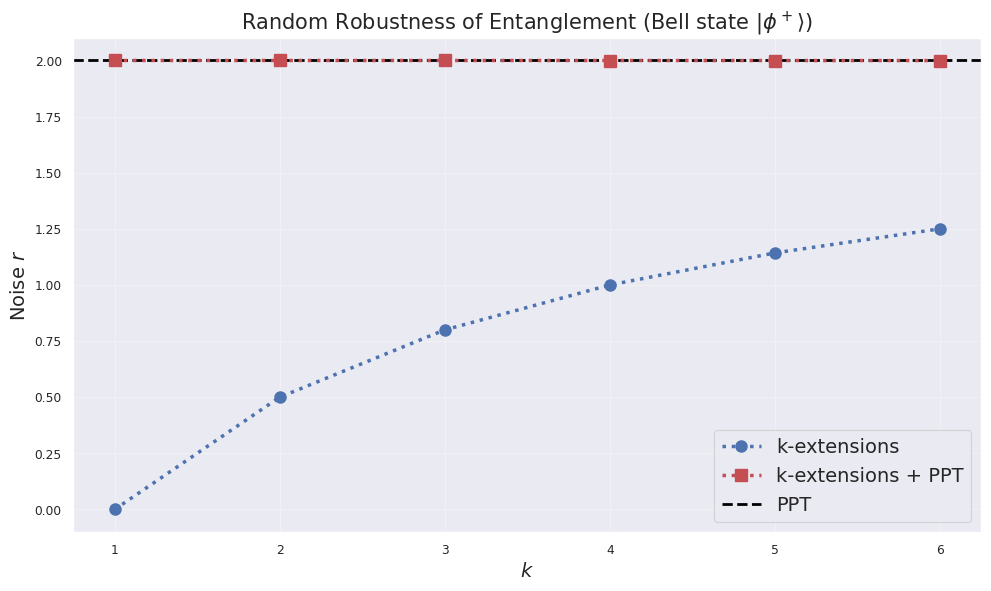

In [31]:
# Bell state
dA, dB = 2, 2
bell = np.array([1, 0, 0, 1]) / np.sqrt(2)
rho_bell = np.outer(bell, bell.conj())

data = np.loadtxt('Bell_results.txt', skiprows=1)

k = data[:, 0]
r_k = data[:, 1]
r_PPT_k = data[:, 2]

r_PPT = RRE_PPT(rho_bell, dA, dB)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(k, r_k, 'bo-', linewidth=2.5, markersize=8, 
        label='k-extensions', zorder=3, linestyle=':')

ax.plot(k, r_PPT_k, 'rs-', linewidth=2.5, markersize=8, 
        label='k-extensions + PPT', zorder=4, linestyle=':') 

ax.axhline(y=r_PPT, color='black', linestyle='--', linewidth=2, 
           alpha=1, label='PPT', zorder=1)
ax.set_title(r'Random Robustness of Entanglement (Bell state $|\phi^+\rangle$)', fontsize=15)
ax.set_xlabel(r'$k$', fontsize=14)
ax.set_ylabel(r'Noise $r$', fontsize=14)
ax.set_xticks(k)
ax.legend(fontsize=14)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig('images/Bell_entanglement.pdf', dpi=300)
fig.show()

In [35]:
# Example with Werner state
def werner(p):
    psi_minus = np.array([0, 1, -1, 0]) / np.sqrt(2)
    rho_singlet = np.outer(psi_minus, psi_minus.conj())
    return p * rho_singlet + (1-p) * np.eye(4)/4

rho_W = werner(0.6)

K = 6

r_k = []
r_PPT_k = []

filename = "Werner_results.txt"

with open(filename, "w") as f:
    f.write("k\tr_k\tr_PPT_k\n")

for k in range(1, K + 1):
    r1, _ = RRE_k(rho_W, dA, dB, k)
    r_k.append(r1)
    r2, _ = RRE_PPT_k(rho_W, dA, dB, k)
    r_PPT_k.append(r2)

    with open(filename, "a") as f:
        f.write(f"{k}\t{r1:.10e}\t{r2:.10e}\n")

/home/juan_segura/Code/Chaos_and_Complexity/SDP/.venv/lib/python3.14/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:41: UserWarning: The problem has an expression with dimension greater than 2. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


/tmp/ipykernel_99563/3454772378.py:13: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "bo-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(k, r_k, 'bo-', linewidth=2.5, markersize=8,
/tmp/ipykernel_99563/3454772378.py:16: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "rs-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(k, r_PPT_k, 'rs-', linewidth=2.5, markersize=8,
/tmp/ipykernel_99563/3454772378.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


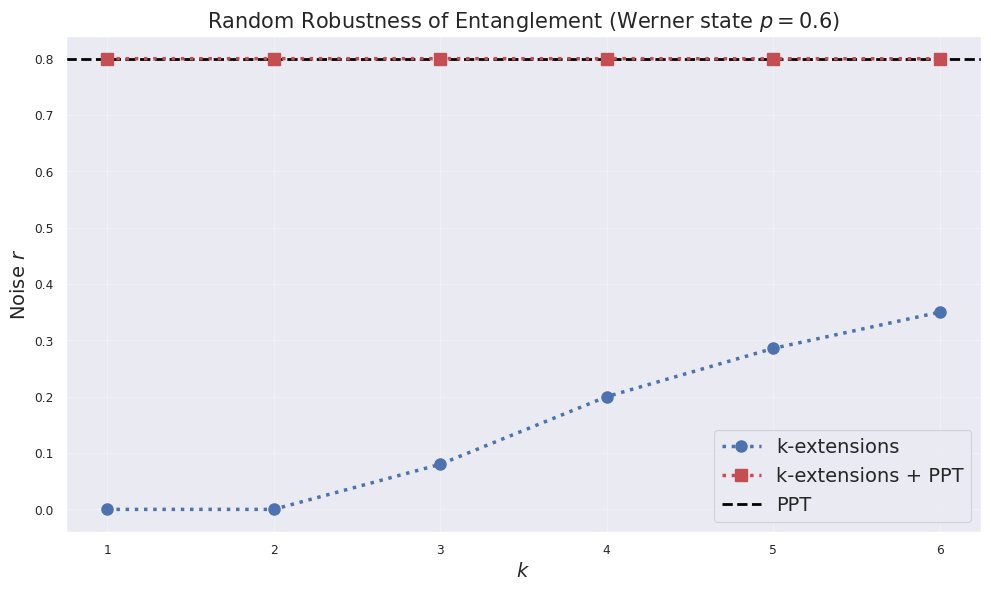

In [36]:
rho_W = werner(0.6)

data = np.loadtxt('Werner_results.txt', skiprows=1)

k = data[:, 0]
r_k = data[:, 1]
r_PPT_k = data[:, 2]

r_PPT = RRE_PPT(rho_W, dA, dB)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(k, r_k, 'bo-', linewidth=2.5, markersize=8, 
        label='k-extensions', zorder=3, linestyle=':')

ax.plot(k, r_PPT_k, 'rs-', linewidth=2.5, markersize=8, 
        label='k-extensions + PPT', zorder=4, linestyle=':') 

ax.axhline(y=r_PPT, color='black', linestyle='--', linewidth=2, 
           alpha=1, label='PPT', zorder=1)
ax.set_title(r'Random Robustness of Entanglement (Werner state $p=0.6$)', fontsize=15)
ax.set_xlabel(r'$k$', fontsize=14)
ax.set_ylabel(r'Noise $r$', fontsize=14)
ax.set_xticks(k)
ax.legend(fontsize=14)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig('images/Werner_entanglement.pdf', dpi=300)
fig.show()

## 6. Measurement Incompatibility

In [37]:
# Random Robustness of Measurement Incompatibility
def RRMI(M_list):
    m = len(M_list)            # Number of measurements
    o = len(M_list[0])         # Number of elements of measurements per each one
    d = M_list[0][0].shape[0]  # Dimension of the measurements

    num_parent = o**m

    # Create the optimization variables
    r = cp.Variable(nonneg=True)
    N = [cp.Variable((d, d), hermitian=True) for _ in range(num_parent)]

    # Constraints
    constraints = []

    for k in range(num_parent):
        constraints.append(N[k] >> 0)

    def outcome(k, x):
        return (k // (o**(m - x - 1))) % o
    
    for x in range(m):
        for a in range(o):
            sum_terms = 0
            for k in range(num_parent):
                if outcome(k, x) == a:
                    sum_terms += N[k]
            
            constraints.append(M_list[x][a] + r * np.eye(d) / o == sum_terms)
    
    constraints.append(sum(N[k] for k in range(num_parent)) == (1 + r) * np.eye(d))

    # Create the problem and solve
    problem = cp.Problem(cp.Minimize(r), constraints)
    problem.solve(solver=cp.SCS, verbose=False)

    return r.value

In [ ]:
# Example with random POVMs
o = 2
m = 4
d = 2

M_list = [random_POVM(o, d) for _ in range(m)]

r = RRMI(M_list)

print(r)

0.11573991590233026


## 7. Quantum Channels